# Trabalho Prático 2 — Pré-processamento e Análise Preditiva
## Notebook 1: Análise Exploratória (Etapas 1 a 5)

**Aluno:** João Victor Borges Carvalho  
**Base:** Breast Cancer Wisconsin (Original) — UCI ML Repository (id=15)  
**Abordagem:** Tudo implementado do zero com Python puro + módulo math  

Aqui eu vou fazer a análise exploratória completa do dataset: carregar os dados, identificar o atributo alvo, classificar os tipos e escalas de cada feature, calcular as estatísticas descritivas, gerar os gráficos e separar o conjunto de teste.

## Configuração e Imports

Carrego as funções do `utils.py` — que é basicamente minha biblioteca pessoal com 40+ funções matemáticas e estatísticas implementadas na mão (sem numpy, sem pandas, sem scipy). A única biblioteca que eu utilizei é o matplotlib pra plotar os gráficos.

In [2]:
import os
import sys
import math

# Garante que o diretório do projeto está no path
PROJECT_DIR = os.path.dirname(os.path.abspath(''))
if PROJECT_DIR not in sys.path:
    sys.path.insert(0, PROJECT_DIR)

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

from utils import (
    load_csv, parse_dataset, extract_column, count_target,
    calc_mean, calc_median, calc_mode,
    calc_variance, calc_std, calc_min, calc_max, calc_range,
    calc_percentile, calc_quartiles, calc_iqr,
    describe, format_percent,
    stratified_split,
)

DATA_PATH = os.path.join('data', 'breast_cancer_wisconsin.csv')
PLOTS_DIR = 'plots'
os.makedirs(PLOTS_DIR, exist_ok=True)

print('Ambiente configurado. utils.py importado com sucesso.')

Ambiente configurado. utils.py importado com sucesso.


## Carregamento dos Dados

Uso o `parse_dataset` do utils.py pra carregar o CSV. Ele já faz algumas coisas importantes de cara:
- Filtra as 16 linhas que têm Bare_nuclei vazio (sim, tem dado faltante no dataset original)
- Converte o target de 2/4 pra 0/1 (bem mais prático pra tudo que vem depois)

O dataset tem 699 amostras de tecido mamário, cada uma com 9 características celulares avaliadas por patologistas numa escala de 1 a 10. A coluna `Class` diz se o tumor é benigno (2) ou maligno (4).

In [3]:
header, X, y, mask = parse_dataset(DATA_PATH)

n_total = len(y)
n_valid = sum(mask)
n_invalid = n_total - n_valid

print(f'Linhas carregadas: {n_total}')
print(f'Linhas válidas:    {n_valid}')
print(f'Linhas com dados ausentes: {n_invalid}')
print(f'Colunas: {len(header)} ({len(header) - 1} features + 1 target)')
print(f'\nFeatures: {header[:-1]}')
print(f'Target:   {header[-1]}')

Linhas carregadas: 699
Linhas válidas:    683
Linhas com dados ausentes: 16
Colunas: 10 (9 features + 1 target)

Features: ['Clump_thickness', 'Uniformity_of_cell_size', 'Uniformity_of_cell_shape', 'Marginal_adhesion', 'Single_epithelial_cell_size', 'Bare_nuclei', 'Bland_chromatin', 'Normal_nucleoli', 'Mitoses']
Target:   Class


## Etapa 1 — Identificação do Atributo Alvo

O atributo alvo é a coluna `Class`, que fica na última posição do CSV (índice 9). As classes originais são:
- `2` → Tumor BENIGNO  
- `4` → Tumor MALIGNO  

Eu converti `2` para `0` (benigno) e `4` para `1` (maligno) logo de cara. Trabalhar com 0 e 1 simplifica tudo que vem depois: cálculo de distância euclidiana no K-NN, função sigmoide na rede neural, interpretação das probabilidades.

## Etapa 2 — Tipos de Dados dos Atributos de Entrada

Agora vou classificar cada feature: é quantitativa (números com significado de grandeza) ou qualitativa (categorias)? É discreta ou contínua?

São todas **quantitativas discretas**. Faz sentido — são notas de 1 a 10 dadas por patologistas. Cada valor é um número inteiro que representa a severidade de uma característica celular. O Bare_nuclei aparece com valores tipo `1.0`, `10.0` no CSV original, mas aquele `.0` é só artefato de formatação — o dado real é inteiro.

In [4]:
print(f'{"Atributo":<32} {"Tipo":<24} {"Valores Distintos"}')
print(f'{"-"*32} {"-"*24} {"-"*18}')

for i, name in enumerate(header[:-1]):
    col = extract_column(X, i)
    unique_vals = set(col)
    all_int = all(v == int(v) for v in col if v is not None)
    
    if all_int and len(unique_vals) <= 12:
        tipo = 'Quantitativo Discreto'
    else:
        tipo = 'Quantitativo Contínuo'
    
    print(f'{name:<32} {tipo:<24} {len(unique_vals)} valores distintos')

print()
print('Resumindo: tudo quantitativo discreto. Notas clínicas inteiras de 1 a 10.')
print('O Bare_nuclei aparece como 1.0, 10.0 etc no CSV, mas o .0 é só formatação.')

Atributo                         Tipo                     Valores Distintos
-------------------------------- ------------------------ ------------------
Clump_thickness                  Quantitativo Discreto    10 valores distintos
Uniformity_of_cell_size          Quantitativo Discreto    10 valores distintos
Uniformity_of_cell_shape         Quantitativo Discreto    10 valores distintos
Marginal_adhesion                Quantitativo Discreto    10 valores distintos
Single_epithelial_cell_size      Quantitativo Discreto    10 valores distintos
Bare_nuclei                      Quantitativo Discreto    10 valores distintos
Bland_chromatin                  Quantitativo Discreto    10 valores distintos
Normal_nucleoli                  Quantitativo Discreto    10 valores distintos
Mitoses                          Quantitativo Discreto    9 valores distintos

Resumindo: tudo quantitativo discreto. Notas clínicas inteiras de 1 a 10.
O Bare_nuclei aparece como 1.0, 10.0 etc no CSV, mas o .0 é só

## Etapa 3 — Escala de Dados dos Atributos de Entrada

Agora a parte mais conceitual: classificar a escala de medição de cada atributo (nominal, ordinal, intervalar ou racional). Minha conclusão: todos são **racionais discretos**.

Sei que a escala original é ordinal (1-10), mas na literatura médica essas notas costumam ser tratadas como intervalares/racionais pra permitir operações estatísticas paramétricas.

Achei razoável seguir essa convenção.

In [5]:
print(f'{"Atributo":<32} {"Escala":<20}')
print(f'{"-"*32} {"-"*20}')

for i, name in enumerate(header[:-1]):
    print(f'{name:<32} {"Intervalar Discreta":<20}')

print()
print('Por que escala intervalar?')
print('  1. Intervalos são aproximadamente constantes')
print('  2. Não há zero absoluto verdadeiro (nota 1 = mínimo da escala)')
print('  3. Convenção da literatura médica — tratada como intervalar')
print()
print('A escala original é ordinal (1-10), mas na prática médica')
print('trata-se como intervalar para permitir estatística paramétrica.')

Atributo                         Escala              
-------------------------------- --------------------
Clump_thickness                  Intervalar Discreta 
Uniformity_of_cell_size          Intervalar Discreta 
Uniformity_of_cell_shape         Intervalar Discreta 
Marginal_adhesion                Intervalar Discreta 
Single_epithelial_cell_size      Intervalar Discreta 
Bare_nuclei                      Intervalar Discreta 
Bland_chromatin                  Intervalar Discreta 
Normal_nucleoli                  Intervalar Discreta 
Mitoses                          Intervalar Discreta 

Por que escala intervalar?
  1. Intervalos são aproximadamente constantes
  2. Não há zero absoluto verdadeiro (nota 1 = mínimo da escala)
  3. Convenção da literatura médica — tratada como intervalar

A escala original é ordinal (1-10), mas na prática médica
trata-se como intervalar para permitir estatística paramétrica.


## Etapa 4a — Medidas de Localidade (Tendência Central)

Agora começa a parte mais braçal: calcular média, mediana e moda pra cada feature. Todas as funções são do `utils.py` — implementadas com Python puro, sem atalhos.

O que eu já esperava encontrar: a moda da maioria dos atributos deve ser 1 (o valor mínimo da escala), porque a maior parte das amostras provavelmente tem baixa severidade nas características celulares. Se a média for bem maior que a mediana, já sei que a distribuição é assimétrica à direita.

In [6]:
print(f'{"Atributo":<32} {"Média":>8} {"Mediana":>8} {"Moda(s)":>15}')
print(f'{"-"*32} {"-"*8} {"-"*8} {"-"*15}')

for i, name in enumerate(header[:-1]):
    col = extract_column(X, i, mask)
    mean_val = calc_mean(col)
    median_val = calc_median(col)
    mode_val = calc_mode(col)
    mode_str = ', '.join(str(int(m)) for m in sorted(mode_val)[:3])
    print(f'{name:<32} {mean_val:>8.2f} {median_val:>8.1f} {mode_str:>15}')

Atributo                            Média  Mediana         Moda(s)
-------------------------------- -------- -------- ---------------
Clump_thickness                      4.44      4.0               1
Uniformity_of_cell_size              3.15      1.0               1
Uniformity_of_cell_shape             3.22      1.0               1
Marginal_adhesion                    2.83      1.0               1
Single_epithelial_cell_size          3.23      2.0               2
Bare_nuclei                          3.54      1.0               1
Bland_chromatin                      3.45      3.0               3
Normal_nucleoli                      2.87      1.0               1
Mitoses                              1.60      1.0               1


## Etapa 4b — Medidas de Espalhamento (Dispersão)

Agora amplitude, variância, desvio padrão e IQR (intervalo interquartil). A dispersão me diz o quanto os valores variam dentro de cada feature.

Minha aposta: Bare_nuclei deve ser o atributo mais disperso, e Mitoses o mais concentrado. Se Mitoses tiver IQR = 0, já sei que quase todo mundo tem valor 1 nessa feature — o que sugere que ela talvez não seja tão útil pra diferenciar benigno de maligno.

In [7]:
print(f'{"Atributo":<32} {"Amplitude":>10} {"Variância":>10} {"Desv.Pad.":>10} {"IQR":>8}')
print(f'{"-"*32} {"-"*10} {"-"*10} {"-"*10} {"-"*8}')

for i, name in enumerate(header[:-1]):
    col = extract_column(X, i, mask)
    amp = calc_range(col)
    var = calc_variance(col)
    std = calc_std(col)
    iqr = calc_iqr(col)
    print(f'{name:<32} {amp:>10.2f} {var:>10.4f} {std:>10.4f} {iqr:>8.2f}')

Atributo                          Amplitude  Variância  Desv.Pad.      IQR
-------------------------------- ---------- ---------- ---------- --------
Clump_thickness                        9.00     7.9567     2.8208     4.00
Uniformity_of_cell_size                9.00     9.3951     3.0651     4.00
Uniformity_of_cell_shape               9.00     8.9316     2.9886     4.00
Marginal_adhesion                      9.00     8.2057     2.8646     3.00
Single_epithelial_cell_size            9.00     4.9421     2.2231     2.00
Bare_nuclei                            9.00    13.2777     3.6439     5.00
Bland_chromatin                        9.00     6.0010     2.4497     3.00
Normal_nucleoli                        9.00     9.3188     3.0527     3.00
Mitoses                                9.00     3.0022     1.7327     0.00


## Etapa 4c — Medidas de Distribuição (Gráficos)

Vou gerar três gráficos:
1. Distribuição das classes (barras) — pra ver se o dataset é balanceado
2. Histogramas por classe (grid 3×3) — pra ver quais features discriminam melhor benigno vs maligno
3. Boxplots por classe (grid 3×3) — pra detectar assimetria, outliers e diferença de dispersão entre classes

### Distribuição das Classes

Primeiro uma visão geral: quantos casos benignos e malignos tem no dataset? Se a razão for maior que 2:1, talvez eu precise de balanceamento mais pra frente.

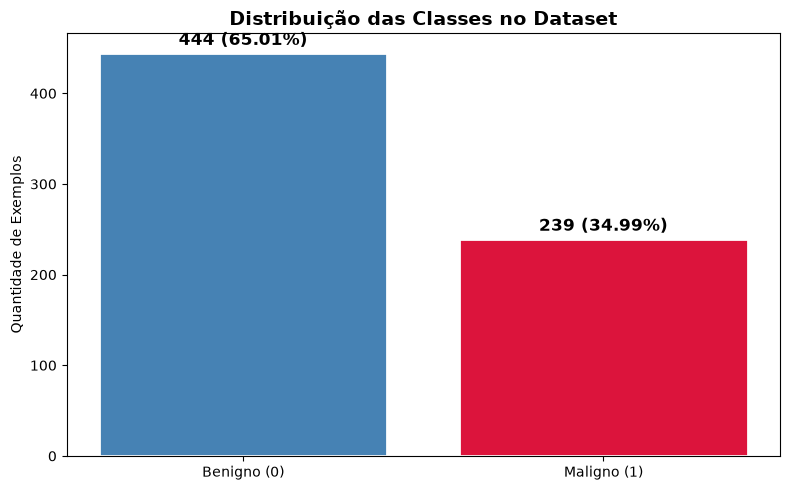

Benignos (0): 444 (65.01%)
Malignos  (1): 239 (34.99%)
Razão benigno/maligno: 444/239 ≈ 1.86:1

Minha leitura: Dataset relativamente balanceado (razão 1.86:1 < 2:1).
Provavelmente não vou precisar nem undersampling.


In [8]:
y_valid_full = [y[i] for i in range(len(y)) if mask[i]]
counts = count_target(y_valid_full)
total = sum(counts.values())
labels = ['Benigno (0)', 'Maligno (1)']
values = [counts.get(0, 0), counts.get(1, 0)]
colors = ['steelblue', 'crimson']

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(labels, values, color=colors, edgecolor='white', linewidth=2)
for bar, v in zip(bars, values):
    pct = f'{v} ({format_percent(v, total)})'
    ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 5,
            pct, ha='center', va='bottom', fontsize=12, fontweight='bold')
ax.set_title('Distribuição das Classes no Dataset', fontsize=14, fontweight='bold')
ax.set_ylabel('Quantidade de Exemplos')
plt.tight_layout()
plt.savefig(os.path.join(PLOTS_DIR, 'distribuicao_classes.png'), dpi=150, bbox_inches='tight')
plt.show()

ratio = values[0] / values[1] if values[1] > 0 else float('inf')
print(f'Benignos (0): {values[0]} ({format_percent(values[0], total)})')
print(f'Malignos  (1): {values[1]} ({format_percent(values[1], total)})')
print(f'Razão benigno/maligno: {values[0]}/{values[1]} ≈ {ratio:.2f}:1')
print(f'\nMinha leitura: Dataset relativamente balanceado (razão {ratio:.2f}:1 < 2:1).')
print(f'Provavelmente não vou precisar nem undersampling.')

### Histogramas por Classe (grid 3×3)

Gero histogramas sobrepostos pra cada atributo, separando benigno (azul) e maligno (vermelho). O que eu quero ver aqui: em quais features as distribuições são bem diferentes entre as classes? Se benigno e maligno têm histogramas parecidos, aquela feature provavelmente não ajuda muito na classificação.

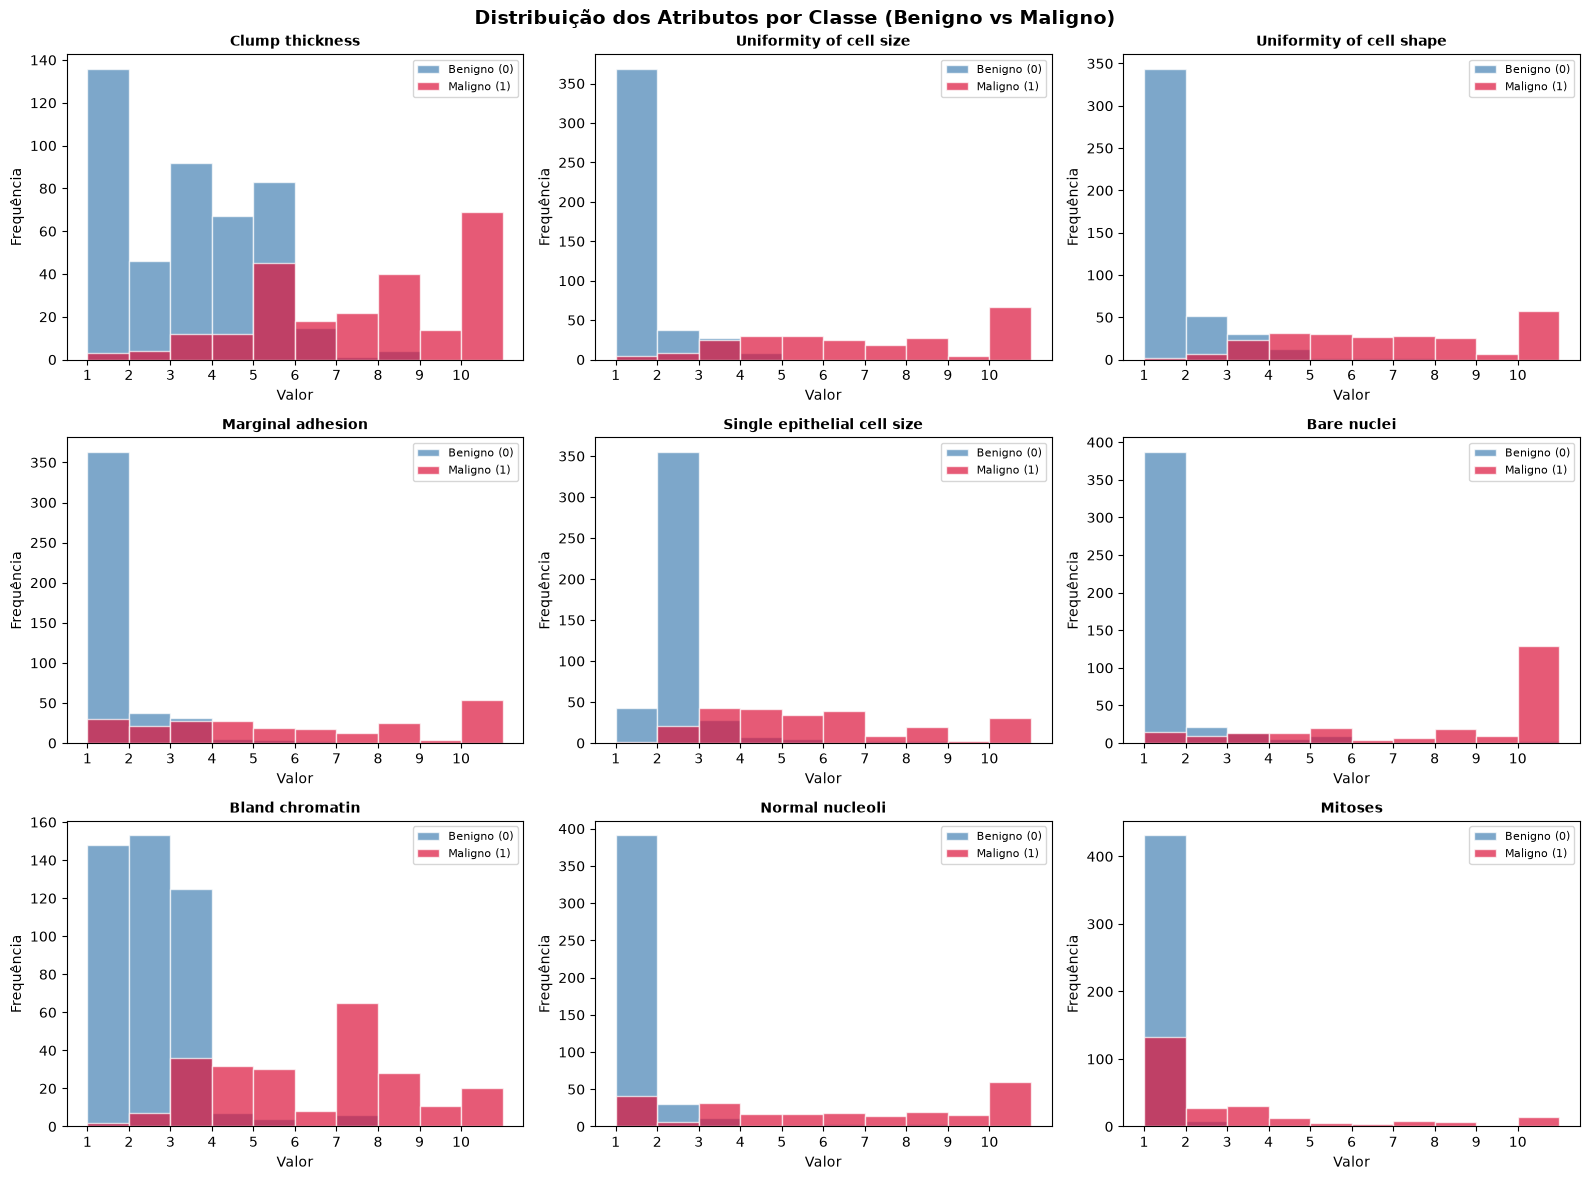

In [9]:
idx_benign = [i for i, val in enumerate(y) if val == 0 and mask[i]]
idx_malign = [i for i, val in enumerate(y) if val == 1 and mask[i]]

fig, axes = plt.subplots(3, 3, figsize=(16, 12))
axes = axes.flatten()

for i, (name, ax) in enumerate(zip(header[:-1], axes)):
    col_benign = [X[j][i] for j in idx_benign if X[j][i] is not None]
    col_malign = [X[j][i] for j in idx_malign if X[j][i] is not None]
    bins = range(1, 12)
    ax.hist(col_benign, bins=bins, alpha=0.7, label='Benigno (0)', color='steelblue', edgecolor='white')
    ax.hist(col_malign, bins=bins, alpha=0.7, label='Maligno (1)', color='crimson', edgecolor='white')
    ax.set_title(name.replace('_', ' '), fontsize=10, fontweight='bold')
    ax.set_xlabel('Valor')
    ax.set_ylabel('Frequência')
    ax.legend(fontsize=8)
    ax.set_xticks(range(1, 11))

plt.suptitle('Distribuição dos Atributos por Classe (Benigno vs Maligno)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(PLOTS_DIR, 'histogramas_por_classe.png'), dpi=150, bbox_inches='tight')
plt.show()

### Boxplots por Classe (grid 3×3)

Mesmo grid 3×3, mas agora com boxplots. Bons pra detectar assimetria, outliers e diferença de dispersão entre as classes. Se a caixa azul (benigno) ficar lá embaixo e a vermelha (maligno) lá em cima, já sei que aquela feature é um ótimo discriminador.

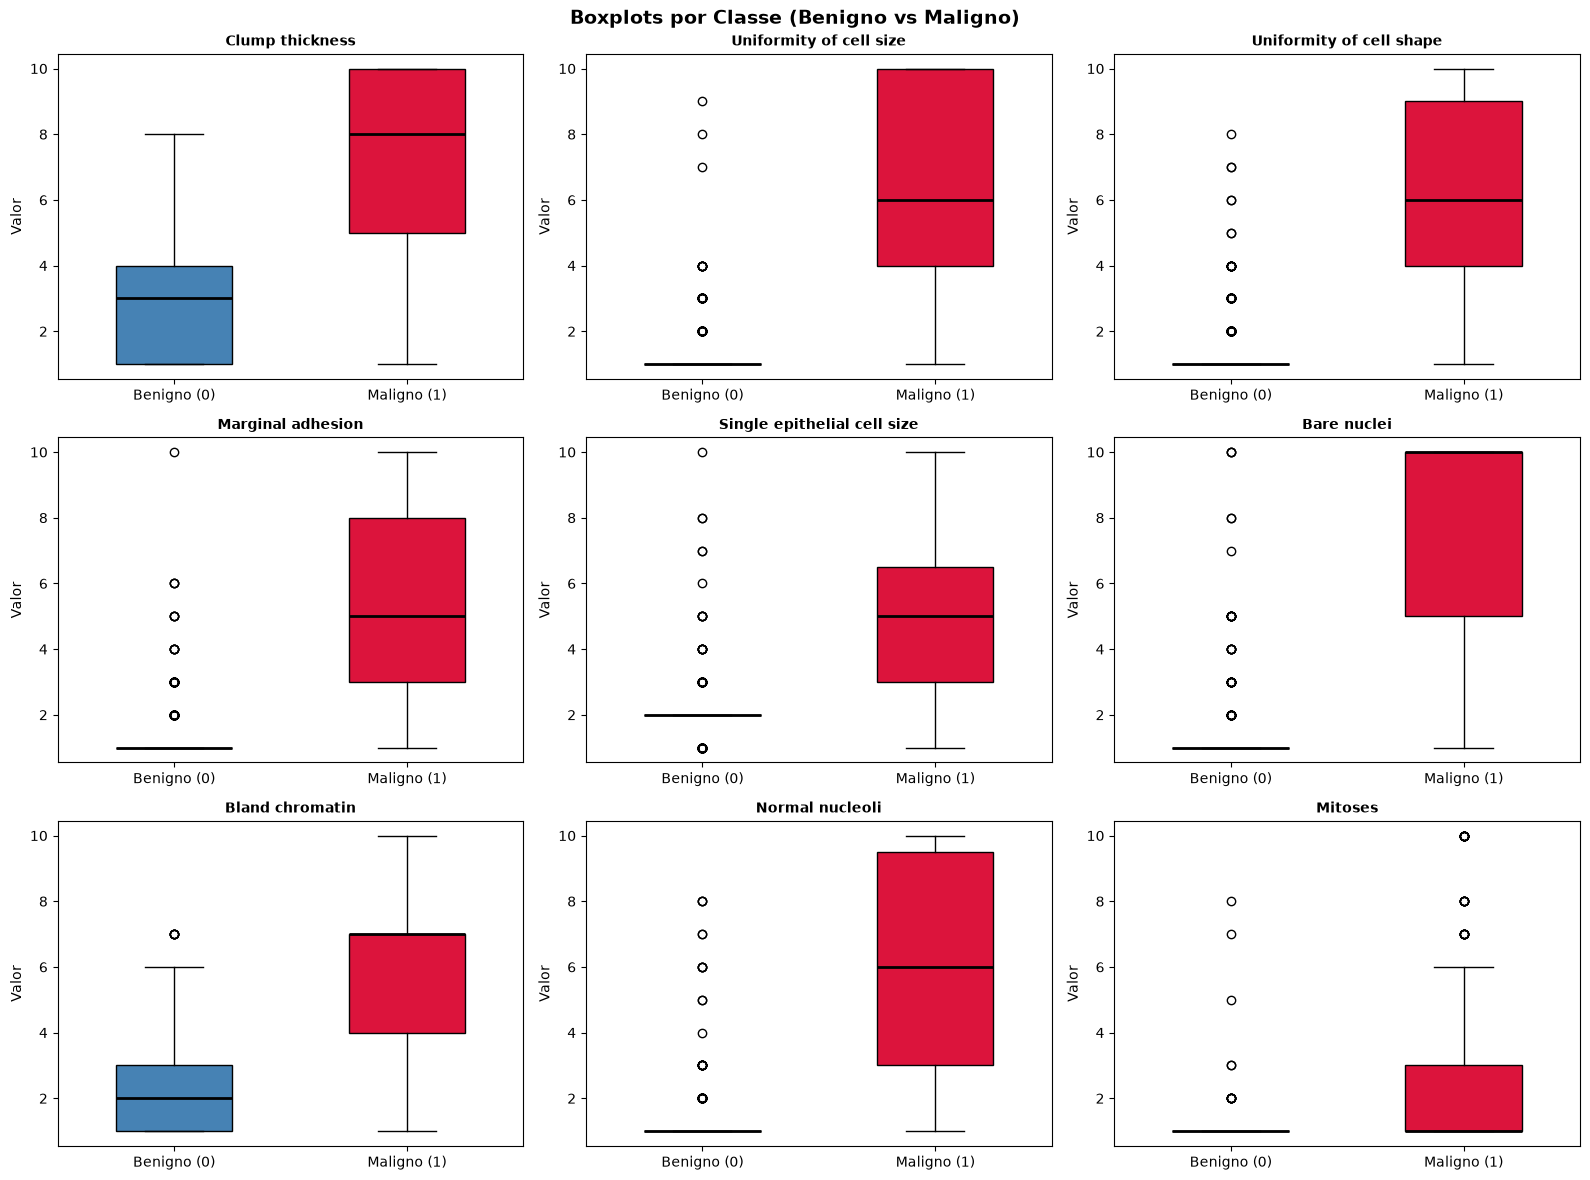

In [10]:
fig, axes = plt.subplots(3, 3, figsize=(16, 12))
axes = axes.flatten()

for i, (name, ax) in enumerate(zip(header[:-1], axes)):
    col_benign = [X[j][i] for j in idx_benign if X[j][i] is not None]
    col_malign = [X[j][i] for j in idx_malign if X[j][i] is not None]
    bp = ax.boxplot([col_benign, col_malign], patch_artist=True,
                    medianprops={'color': 'black', 'linewidth': 2}, widths=0.5)
    ax.set_xticklabels(['Benigno (0)', 'Maligno (1)'])
    bp['boxes'][0].set_facecolor('steelblue')
    bp['boxes'][1].set_facecolor('crimson')
    ax.set_title(name.replace('_', ' '), fontsize=10, fontweight='bold')
    ax.set_ylabel('Valor')

plt.suptitle('Boxplots por Classe (Benigno vs Maligno)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(PLOTS_DIR, 'boxplots_por_classe.png'), dpi=150, bbox_inches='tight')
plt.show()

## Etapa 5 — Separação do Conjunto de Teste

Essa etapa é crucial. Vou separar 20% dos dados pra teste usando hold-out com amostragem estratificada. A seed=42 garante que toda vez que eu rodar, a divisão é a mesma.

A estratificação é importante porque mantém a proporção de malignos (~35%) igual no treino e no teste. Se eu fizesse uma divisão aleatória simples, podia cair uma proporção diferente em cada conjunto e isso bagunçaria a avaliação.

O conjunto de teste vai ficar intocado até o final — não vou usar ele em NENHUM momento do pré-processamento. Isso é essencial pra simular um cenário real, onde os dados novos chegam depois que o modelo já está treinado.

In [11]:
# Trabalhamos apenas com linhas válidas
X_valid = [X[i] for i in range(len(X)) if mask[i]]
y_valid = [y[i] for i in range(len(y)) if mask[i]]

counts_orig = count_target(y_valid)
total_valid = sum(counts_orig.values())

print(f'Exemplos válidos disponíveis: {len(y_valid)}')
print(f'Distribuição original:')
print(f'  Benigno (0): {counts_orig[0]} ({format_percent(counts_orig[0], total_valid)})')
print(f'  Maligno  (1): {counts_orig[1]} ({format_percent(counts_orig[1], total_valid)})')

# Divisão estratificada 80/20 com seed=42
X_train, X_test, y_train, y_test = stratified_split(X_valid, y_valid, test_ratio=0.2, seed=42)

counts_train = count_target(y_train)
counts_test = count_target(y_test)
total_train = sum(counts_train.values())
total_test = sum(counts_test.values())

print(f'\nConjunto de TREINAMENTO ({total_train} exemplos, {format_percent(total_train, total_valid)}):')
print(f'  Benigno (0): {counts_train[0]} ({format_percent(counts_train[0], total_train)})')
print(f'  Maligno  (1): {counts_train[1]} ({format_percent(counts_train[1], total_train)})')

print(f'\nConjunto de TESTE ({total_test} exemplos, {format_percent(total_test, total_valid)}):')
print(f'  Benigno (0): {counts_test[0]} ({format_percent(counts_test[0], total_test)})')
print(f'  Maligno  (1): {counts_test[1]} ({format_percent(counts_test[1], total_test)})')

# Verificação de representatividade
prop_orig = counts_orig[1] / total_valid
prop_train = counts_train[1] / total_train
prop_test = counts_test[1] / total_test

print(f'\nVerificação de representatividade:')
print(f'  Proporção original de malignos: {prop_orig:.4f}')
print(f'  Proporção no treino:            {prop_train:.4f} (delta: {abs(prop_train - prop_orig):.4f})')
print(f'  Proporção no teste:             {prop_test:.4f}  (delta: {abs(prop_test - prop_orig):.4f})')

if abs(prop_train - prop_orig) < 0.03 and abs(prop_test - prop_orig) < 0.03:
    print(f'\nConjunto de teste REPRESENTATIVO (proporções mantidas).')
else:
    print(f'\nDivergência na proporção — verificar amostragem.')

print(f'\nPor que hold-out e não cross-validation?')
print(f'  - Hold-out 80/20 com estratificação garante que ambas as classes')
print(f'  estejam representadas proporcionalmente no treino e no teste.')
print(f'  - Seed=42 garante reprodutibilidade.')
print(f'  - Cross-validation seria mais robusta, mas como implementei tudo')
print(f'  na mão, rodar 5-fold com 3 algoritmos diferentes seria bem custoso.')

Exemplos válidos disponíveis: 683
Distribuição original:
  Benigno (0): 444 (65.01%)
  Maligno  (1): 239 (34.99%)

Conjunto de TREINAMENTO (546 exemplos, 79.94%):
  Benigno (0): 355 (65.02%)
  Maligno  (1): 191 (34.98%)

Conjunto de TESTE (137 exemplos, 20.06%):
  Benigno (0): 89 (64.96%)
  Maligno  (1): 48 (35.04%)

Verificação de representatividade:
  Proporção original de malignos: 0.3499
  Proporção no treino:            0.3498 (delta: 0.0001)
  Proporção no teste:             0.3504  (delta: 0.0004)

Conjunto de teste REPRESENTATIVO (proporções mantidas).

Por que hold-out e não cross-validation?
  - Hold-out 80/20 com estratificação garante que ambas as classes
  estejam representadas proporcionalmente no treino e no teste.
  - Seed=42 garante reprodutibilidade.
  - Cross-validation seria mais robusta, mas como implementei tudo
  na mão, rodar 5-fold com 3 algoritmos diferentes seria bem custoso.


## Fim do Notebook 1

- Dataset com 683 exemplos válidos (16 perdidos por dados ausentes)
- Todas as 9 features são quantitativas discretas em escala intervalar
- Distribuição assimétrica à direita (moda=1 pra maioria, mas média > mediana)
- Bare_nuclei é o atributo mais disperso; Mitoses o mais concentrado
- Razão benigno/maligno de ~1.9:1 (relativamente balanceado)
- Divisão treino/teste com 546/137 exemplos e proporções preservadas

As variáveis `X_train`, `X_test`, `y_train`, `y_test` estão prontas pro **Notebook 2** (Pré-processamento). Bora continuar!